#***Libraries***

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

#***Download Data***


In [ ]:
# Install the Kaggle Hub package to download datasets
!pip install kagglehub -q

# Import the kagglehub library
import kagglehub

# Download the TrashNet dataset from Kaggle
path = kagglehub.dataset_download("feyzazkefe/trashnet")

# Print the path where the dataset is saved on the computer
print("Path:", path)

Using Colab cache for faster access to the 'trashnet' dataset.
Path: /kaggle/input/trashnet


#***Data Exploration***

In [ ]:
# Path to the main TrashNet dataset folder
dataset_path = "/kaggle/input/trashnet"

# First, show what is inside the main folder
print("Contents of main folder:")
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        count = len(os.listdir(item_path))
        print(f"  Folder: {item} - {count} files")
    else:
        print(f"  File: {item}")

# The actual images are in the 'dataset-resized' subfolder
resized_path = os.path.join(dataset_path, "dataset-resized")
if os.path.exists(resized_path):
    print("\nContents of dataset-resized (class folders with image counts):")
    for item in os.listdir(resized_path):
        item_path = os.path.join(resized_path, item)
        if os.path.isdir(item_path):
            count = len(os.listdir(item_path))
            print(f"  {item}: {count} image")
else:
    print("\n dataset-resized folder not found!")

Contents of main folder:
  Folder: dataset-resized - 6 files

Contents of dataset-resized (class folders with image counts):
  metal: 410 image
  glass: 501 image
  paper: 594 image
  trash: 137 image
  cardboard: 403 image
  plastic: 482 image


#***Data Pre-processing***

In [ ]:
dataset_path = "/kaggle/input/trashnet/dataset-resized"
classes = ["glass", "paper", "cardboard", "plastic", "metal", "trash"]

images = []
labels = []

# Load original images
for idx, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    count = 0
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        # Resize to 224x224 and normalize pixel values to [0,1]
        img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img = tf.keras.utils.img_to_array(img) / 255.0
        images.append(img)
        labels.append(idx)
        count += 1
    print(f"{cls}: {count} images")

# Data augmentation pipeline (flip, rotation, brightness)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomBrightness(0.2)
])

# Target count per class to reduce imbalance (at least 450 images)
target_counts = {"cardboard": 450, "metal": 450, "trash": 450}

# Apply augmentation only to underrepresented classes
for cls_name, target in target_counts.items():
    cls_idx = classes.index(cls_name)
    cls_images = [img for img, lbl in zip(images, labels) if lbl == cls_idx]
    current = len(cls_images)
    needed = target - current

    if needed > 0:
        aug_per_image = needed // current + 1  # How many augmented copies per image
        for img in cls_images:
            if needed <= 0:
                break
            img_batch = np.expand_dims(img, 0)
            for _ in range(aug_per_image):
                if needed <= 0:
                    break
                aug_img = augment(img_batch, training=True)[0].numpy()
                images.append(aug_img)
                labels.append(cls_idx)
                needed -= 1

# Count final distribution
from collections import Counter
final_counts = Counter(labels)
for i, cls in enumerate(classes):
    print(f"{cls}: {final_counts[i]} images (original + augmented)")

X = np.array(images)
y = tf.keras.utils.to_categorical(labels, num_classes=6)  # One-hot encode labels

# Split data: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y  # Preserve class distribution
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print("Done.")

glass: 501 images
paper: 594 images
cardboard: 403 images
plastic: 482 images
metal: 410 images
trash: 137 images
glass: 501 images (original + augmented)
paper: 594 images (original + augmented)
cardboard: 450 images (original + augmented)
plastic: 482 images (original + augmented)
metal: 450 images (original + augmented)
trash: 450 images (original + augmented)

Train: 2048 | Validation: 439 | Test: 440
Done.


#***Model Training***

In [ ]:
# Load MobileNetV2 pre-trained on ImageNet (without top classification layer)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze the base model weights

# Build the full model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),     # Convert feature maps to a single vector
    Dense(256, activation='relu'), # Fully connected layer
    Dropout(0.5),                 # Dropout to prevent overfitting
    Dense(6, activation='softmax') # Output layer for 6 classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("Training...")
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=32,
                    verbose=1)
print("Done.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training...
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 297ms/step - accuracy: 0.6377 - loss: 1.0192 - val_accuracy: 0.7722 - val_loss: 0.6703
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7817 - loss: 0.6307 - val_accuracy: 0.7836 - val_loss: 0.5931
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8247 - loss: 0.4996 - val_accuracy: 0.7973 - val_loss: 0.5742
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8433 - loss: 0.4516 - val_accuracy: 0.7973 - val_loss: 0.5488
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8633 - loss: 0.3924 - val_accuracy: 0.7882 - val_loss: 0.5266
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9014 - loss: 0.3088 - val_accuracy: 0.8109 - val_loss: 0.5435
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9097 - loss: 0.2848 - val_accuracy: 0.8269 - val_loss: 0.5361
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/st

# ***Evaluation and Visualization***

Test Accuracy: 84.32%


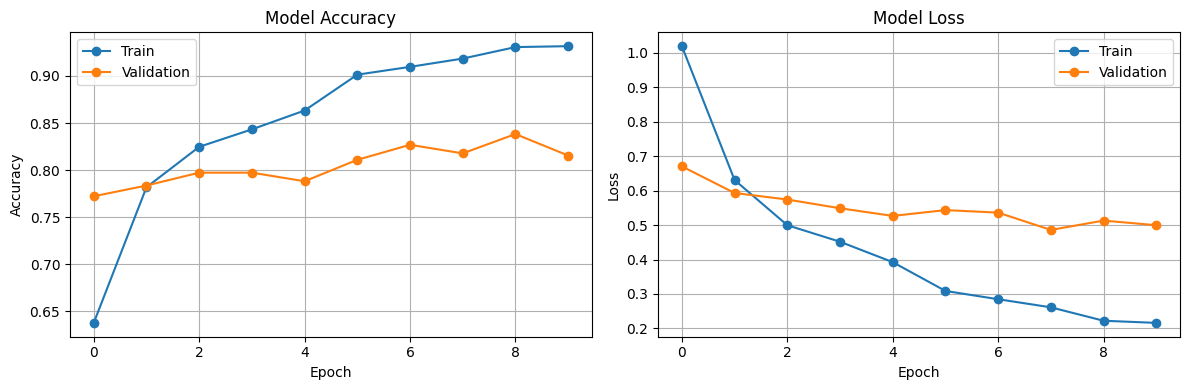

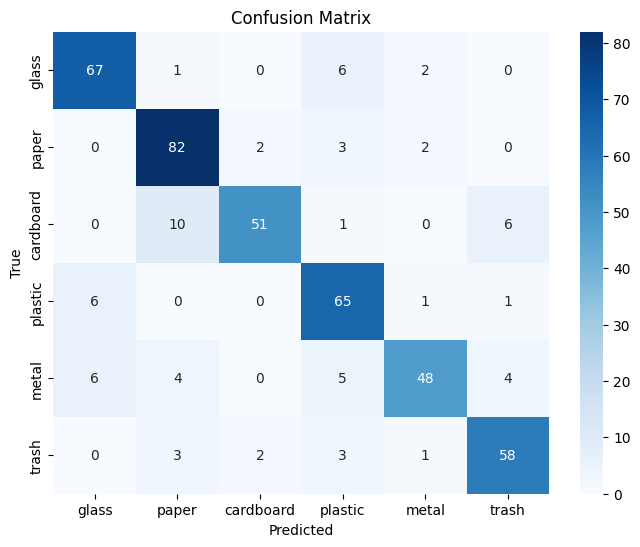

Classification Report:
              precision    recall  f1-score   support

       glass       0.85      0.88      0.86        76
       paper       0.82      0.92      0.87        89
   cardboard       0.93      0.75      0.83        68
     plastic       0.78      0.89      0.83        73
       metal       0.89      0.72      0.79        67
       trash       0.84      0.87      0.85        67

    accuracy                           0.84       440
   macro avg       0.85      0.84      0.84       440
weighted avg       0.85      0.84      0.84       440



In [ ]:
# Class names in order
classes = ["glass", "paper", "cardboard", "plastic", "metal", "trash"]

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train', marker='o')
plt.plot(history.history['val_loss'], label='Validation', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Predict on test set
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)    # Convert probabilities to class index
y_true_classes = np.argmax(y_test, axis=1)   # Convert one-hot to class index

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print precision, recall, and F1-score for each class
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes, zero_division=0))